In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# About

In [2]:
models = "WT G43A G43C G43U C27A C27G C27U A9C G24A".split()
tids = [f"{i:02}" for i in range(0, 12)]

plt.rcParams.update({'font.size': 8})
plt.rcParams.update({'font.family': "Open Sans"})

### Fig 6C: H-bonds hinge

Text(0, 0.5, 'H-bonds')

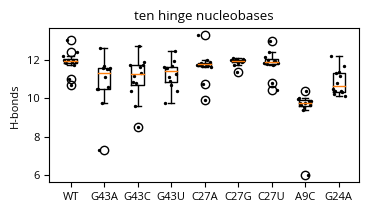

In [4]:
# initialize figure
fig, ax = plt.subplots(figsize=(4, 2))

# initialize containers
means_all = []
xs = []
xs_means = []
means = []
rmsfs_models = []

x = 0
x_mean = 6
gap = 15

for model_i, model in enumerate(models):
    
    means = []
    
    for tid in tids:
        
        # read data
        xvg = f"../systems/{model}/hbonds.hinge.{tid}.xvg"
        times, hbonds, pairs = np.loadtxt(xvg, comments="# @ &".split()).T
        
        # normalize length of the trajectories
        # analyze only the later parts
        times = times[7500:12500]
        hbonds = hbonds[7500:12500]
        
        means.append(np.mean(hbonds))
        
        xs.append(x)
        x += 1
           
    xs_means.append(x_mean)
    means_all.append(means)
    
    x += gap
    x_mean += (12 + gap)

# plot
ax.scatter(xs, np.array(means_all).flatten(), s=2, color="black")
ax.boxplot(means_all, positions=xs_means, widths=10, labels=models)

# layout
ax.set_title("ten hinge nucleobases")
ax.set_ylabel("H-bonds")

WT MannwhitneyuResult(statistic=72.0, pvalue=1.0)
G43A MannwhitneyuResult(statistic=121.0, pvalue=0.005107905424995494)
G43C MannwhitneyuResult(statistic=116.0, pvalue=0.012022825407617439)
G43U MannwhitneyuResult(statistic=114.0, pvalue=0.01657492674985327)
C27A MannwhitneyuResult(statistic=100.0, pvalue=0.11235119769046395)
C27G MannwhitneyuResult(statistic=71.0, pvalue=0.9769702553219757)
C27U MannwhitneyuResult(statistic=80.0, pvalue=0.6650055421020291)
A9C MannwhitneyuResult(statistic=144.0, pvalue=3.6584553538971e-05)
G24A MannwhitneyuResult(statistic=125.0, pvalue=0.0024367348089890145)


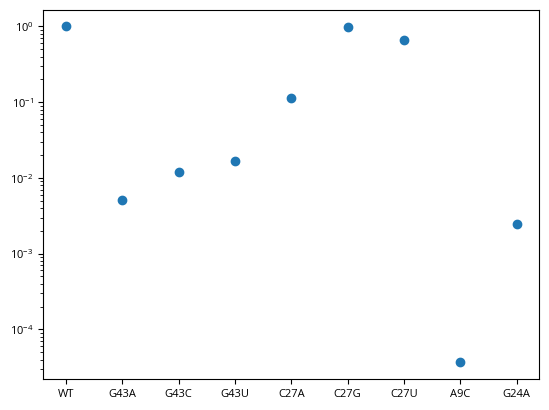

In [5]:
ps = []
for i in range(len(means_all)):
    p = stats.mannwhitneyu(means_all[0], means_all[i])
    ps.append(p.pvalue)
    print(models[i], p)
    
xs = np.arange(len(ps))
plt.scatter(xs, ps)
plt.xticks(xs, labels=models)
plt.yscale("log")

### Fig 6F: Fraction of low-RMSD conformations

[Text(6, 0, 'WT'),
 Text(33, 0, 'G43A'),
 Text(60, 0, 'G43C'),
 Text(87, 0, 'G43U'),
 Text(114, 0, 'C27A'),
 Text(141, 0, 'C27G'),
 Text(168, 0, 'C27U'),
 Text(195, 0, 'A9C'),
 Text(222, 0, 'G24A')]

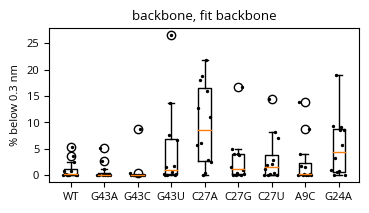

In [7]:
fig, ax = plt.subplots(figsize=(4, 2))

threshold = 0.3

# containers
bars_all = []
xs = []
xs_means = []

x = 0
x_mean = 6
gap = 15

for model_i, model in enumerate(models):
    
    bars = []
    
    for tid in tids:
        
        # read data
        xvg = f"../systems/{model}/rmsd.bb.fitBb.{tid}.xvg"
        times, rmsds = np.loadtxt(xvg, comments="# @ &".split()).T
        
        # normalize length of the trajectories
        times = times[7500:12500]
        rmsds = rmsds[7500:12500]
    
        # histogram
        rmsds = np.array(rmsds)
        hist, edges = np.histogram(rmsds, range=(0,3), bins=300, density=True)

        # cummulative histogram
        cumsum = np.cumsum(hist) * (edges[1] - edges[0])
        threshold_dists = np.square(edges - threshold)
        threshold_index = np.where(threshold_dists < 1e-10)[0]
        bars.append(cumsum[int(threshold_index)] * 100)
        
        xs.append(x)
        x += 1
           
    xs_means.append(x_mean)
    x += gap
    x_mean += (12 + gap)
        
    bars_all.append(bars)
    

ax.scatter(xs, np.array(bars_all).flatten(), s=2, color="black")
boxes = ax.boxplot(bars_all, positions=xs_means, widths=10, labels=models)

ax.set_title("backbone, fit backbone")
ax.set_ylabel(f"% below {threshold} nm")

ax.set_xticklabels(models)

WT MannwhitneyuResult(statistic=72.0, pvalue=1.0)
G43A MannwhitneyuResult(statistic=121.0, pvalue=0.005107905424995494)
G43C MannwhitneyuResult(statistic=116.0, pvalue=0.012022825407617439)
G43U MannwhitneyuResult(statistic=114.0, pvalue=0.01657492674985327)
C27A MannwhitneyuResult(statistic=100.0, pvalue=0.11235119769046395)
C27G MannwhitneyuResult(statistic=71.0, pvalue=0.9769702553219757)
C27U MannwhitneyuResult(statistic=80.0, pvalue=0.6650055421020291)
A9C MannwhitneyuResult(statistic=144.0, pvalue=3.6584553538971e-05)
G24A MannwhitneyuResult(statistic=125.0, pvalue=0.0024367348089890145)


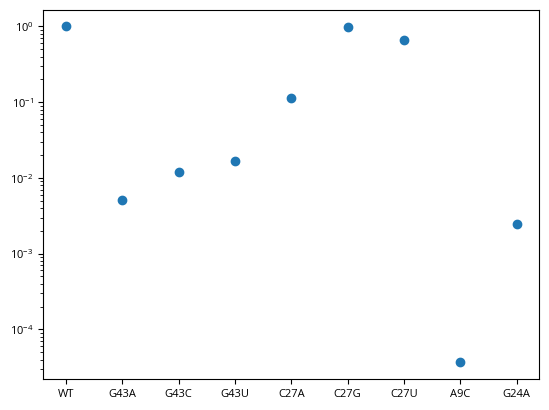

In [8]:
ps = []
for i in range(len(means_all)):
    p = stats.mannwhitneyu(means_all[0], means_all[i])
    ps.append(p.pvalue)
    print(models[i], p)
    
xs = np.arange(len(ps))
plt.scatter(xs, ps)
plt.xticks(xs, labels=models)
plt.yscale("log")

### Fig. 6D: RMSF 

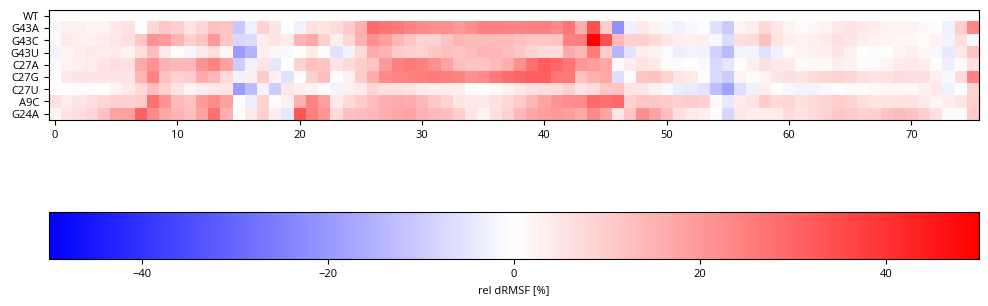

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

means_all = []

for model_i, model in enumerate(models):

    data = []
    
    for tid in tids:
        
        # read data
        xvg = f"../systems/{model}/rmsf.fitNotStem.b150.e250.{tid}.xvg"
        resids, rmsfs = np.loadtxt(xvg, comments="# @ &".split()).T
    
        data.append(rmsfs)
    
    data = np.array(data)
    means = np.mean(data, axis=0)
    stds = np.std(data, axis=0)
    sterrs = stds/ len(tids)**0.5
    
    means_all.append(means)
    
cb = ax.imshow((means_all - means_all[0])/means_all[0]*100, cmap="bwr",
               vmin=-50, vmax=50,
               interpolation=None)

plt.colorbar(cb, orientation="horizontal", label="rel dRMSF [%]")
ax.set_yticks(ticks=range(len(models)), labels=models)


### Suppl. Fig. 6: H-bonds mutated pair 

Text(0, 0.5, 'H-bonds')

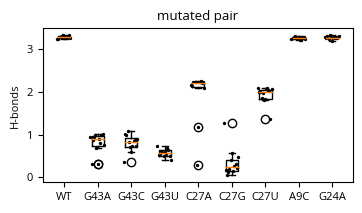

In [12]:
# initialize figure
fig, ax = plt.subplots(figsize=(4, 2))

# initialize containers
means_all = []
xs = []
xs_means = []
means = []
rmsfs_models = []

x = 0
x_mean = 6
gap = 15

for model_i, model in enumerate(models):
    
    means = []
    
    for tid in tids:
        
        # read data
        xvg = f"../systems/{model}/hbonds.mutated.{tid}.xvg"
        times, hbonds, pairs = np.loadtxt(xvg, comments="# @ &".split()).T
        
        # normalize length of the trajectories
        # analyze only the later parts
        times = times[7500:12500]
        hbonds = hbonds[7500:12500]
        
        means.append(np.mean(hbonds))
        
        xs.append(x)
        x += 1
           
    xs_means.append(x_mean)
    means_all.append(means)
    
    x += gap
    x_mean += (12 + gap)

# plot
ax.scatter(xs, np.array(means_all).flatten(), s=2, color="black")
ax.boxplot(means_all, positions=xs_means, widths=10, labels=models)

# layout
ax.set_title("mutated pair")
ax.set_ylabel("H-bonds")

WT MannwhitneyuResult(statistic=72.0, pvalue=1.0)
G43A MannwhitneyuResult(statistic=144.0, pvalue=3.6584553538971e-05)
G43C MannwhitneyuResult(statistic=144.0, pvalue=3.6584553538971e-05)
G43U MannwhitneyuResult(statistic=144.0, pvalue=3.6584553538971e-05)
C27A MannwhitneyuResult(statistic=144.0, pvalue=3.6584553538971e-05)
C27G MannwhitneyuResult(statistic=144.0, pvalue=3.6584553538971e-05)
C27U MannwhitneyuResult(statistic=144.0, pvalue=3.6584553538971e-05)
A9C MannwhitneyuResult(statistic=89.0, pvalue=0.3407786135629546)
G24A MannwhitneyuResult(statistic=84.0, pvalue=0.5067205148778584)


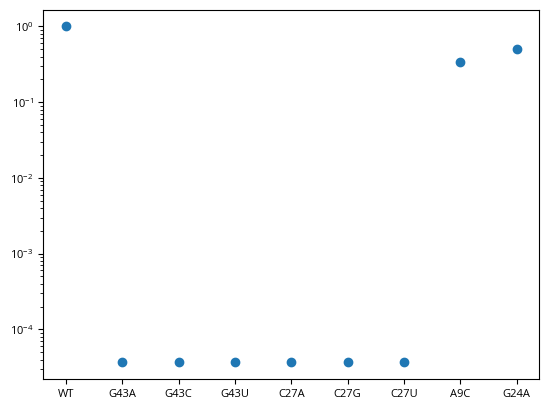

In [13]:
ps = []
for i in range(len(means_all)):
    p = stats.mannwhitneyu(means_all[0], means_all[i])
    ps.append(p.pvalue)
    print(models[i], p)
    
xs = np.arange(len(ps))
plt.scatter(xs, ps)
plt.xticks(xs, labels=models)
plt.yscale("log")